# Student Academic Performance Analysis
### Toby Danon | June 2026

An analysis of the UCI Student Performance dataset (395 Portuguese secondary school students) 
exploring the demographic, behavioural, and academic predictors of final mathematics grades using 
exploratory data analysis, feature engineering, and machine learning models (Linear Regression, Random Forest).

Note: analysis uses the mathematics dataset (student-mat.csv) only. A separate dataset exists for Portuguese language which is not analysed here.

In [495]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Setup Complete")

Setup Complete


In [496]:
df = pd.read_csv("student-mat.csv", sep=";")
df.shape

(395, 33)

In [497]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [498]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [499]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


From the above analysis, the csv file 'student-mat.csv' contains 395 observations with 33 variables and there appears to be no null values in the dataset. From looking at the output from df.describe, we can see that the mean of G3, which represents the students' final grade from 0-20, is 10.42, with a standard deviation of 4.58 and a min and max of 0 and 20 respectively.

<Axes: >

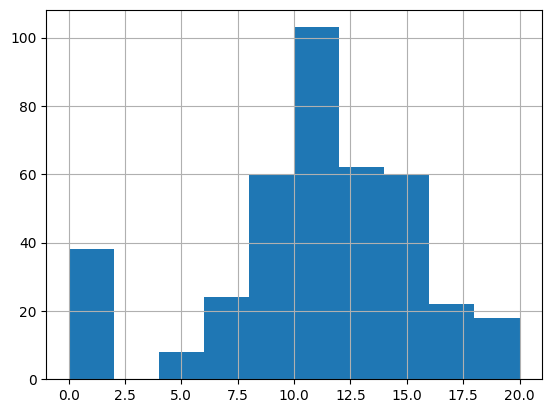

In [501]:
df.G3.hist()

After looking at the data of G3, represented as a histogram, it's clear to see that the students' scores approximately follows a normal distribution, however there are a large group of students who scored 0 on the exam. This may be due to students dropping out and automatically being assigned a grade of 0.

In [502]:
df.groupby("studytime").G3.mean()

studytime
1    10.047619
2    10.171717
3    11.400000
4    11.259259
Name: G3, dtype: float64

Whilst students who study longer hours on average have higher grades, the notion that longer study hours increases grades, whilst true, isn't significant here. Students who study 5-10 hours per week, have a higher average G3 than students who study 10+ hours per week, perhaps due to the fact that students studying 10+ are already struggling or instead because of diminishing returns.

In [503]:
df.groupby("paid").G3.mean()

paid
no      9.985981
yes    10.922652
Name: G3, dtype: float64

Students who had paid tutoring in addition to their school classes score on average 0.938 higher but whilst there is a noticeable difference, paid tutoring doesn't dramatically increase grades.

<Axes: xlabel='absences', ylabel='G3'>

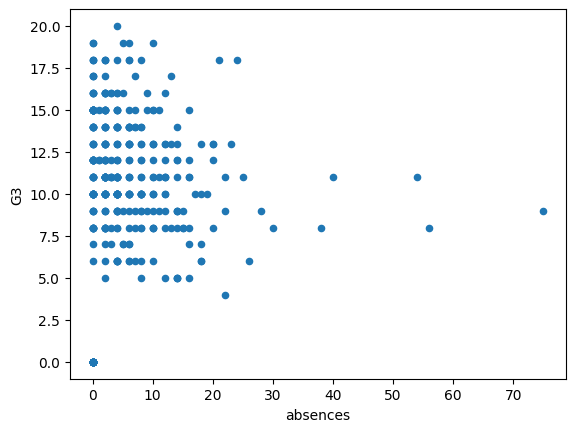

In [504]:
df.plot.scatter(x= "absences", y="G3")

From the scatter plot above, absences don't affect G3 grades of students with 0-25 absences, however all students with 25+ absences score below 12.5 indicating that low level absence from school won't dramatically affect grades however high level absence will.

In [505]:
df.groupby("Medu").G3.mean()

Medu
0    13.000000
1     8.677966
2     9.728155
3    10.303030
4    11.763359
Name: G3, dtype: float64

In [506]:
df.groupby("Fedu").G3.mean()

Fedu
0    13.000000
1     9.158537
2    10.260870
3    10.660000
4    11.364583
Name: G3, dtype: float64

From the data above, it's clear that higher education in both mothers and fathers results in higher final grades for the students, with the effect from both parents being effectively the same. There is a 3 point increase from parents who have education in category 1 vs 4. Also the data shows that parents with 0 education result in an average of 13 but this is likely an anomaly due to 0 observatiosn with both parents having 0 education and only 5 observations with 1 parent having 0 education.

In [508]:
df.loc[:, ["G1", "G2", "G3"]].corr()

,G1,G2,G3
G1,1.000000,0.852118,0.801468
G2,0.852118,1.000000,0.904868
G3,0.801468,0.904868,1.000000


From this output, it's clear that G2 is a stronger predictor of G3 than G1, likely due to G2 being a more recent measure of grades.

In [ ]:
school_sup_int = (df["schoolsup"] == 'yes').astype(int)
fam_sup = (df["famsup"] == 'yes').astype(int)
paid_int = (df["paid"] == 'yes').astype(int)
activities_int = (df["activities"] == 'yes').astype(int)
df['support_score'] = school_sup_int + fam_sup + paid_int + activities_int


support_score
2    150
1    106
3     75
0     53
4     11
Name: count, dtype: int64

In [510]:
df.groupby("support_score").G3.mean()

support_score
0    11.226415
1     9.547170
2    10.566667
3    10.906667
4     9.454545
Name: G3, dtype: float64

The output above shows that students who no assistance achieve the highest grades. This is likely because students who are academic, don't require additional support, meaning that extra help doesn't cause good grades but rather it's a response to bad grades.

In [511]:
failures_int = df["failures"].astype(int)
absences_med = df.absences.median()
above_absences = (df["absences"] > absences_med).astype(int)
go_out_int = df["goout"].astype(int)

df["risk_score"] = failures_int + above_absences + go_out_int
df["risk_score"].value_counts()

risk_score
3    105
4     87
5     71
2     68
6     33
1     12
7      8
8      8
9      3
Name: count, dtype: int64

In [512]:
df.groupby("risk_score").G3.mean()

risk_score
1    11.666667
2    11.558824
3    11.152381
4    10.448276
5     9.211268
6    10.272727
7     6.750000
8     4.750000
9     7.666667
Name: G3, dtype: float64

From the above output, there is a clear trend between higher risk scores and lower G3 means, unlike support scores. Whilst there are large increases for 6 and 9, this is likely due to noise as a result of the relatively small dataset.

In [513]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

In [514]:
df = df[df["G3"] > 0]
X = df.drop(["G3"], axis = 1)
y = df["G3"]

In [515]:
X = pd.get_dummies(X, dtype=int)

In [516]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [517]:
model = LinearRegression().fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_pred, y_test)
r2 = r2_score(y_pred, y_test)

print(mse)
print(r2)

0.8697901107937441
0.9043382273614237


After running a linear regression with G3 as the dependent variable and removing the large outlier group of scores = 0 because students who drop out will likely receive an automatic 0 which skews the data, we can see that the Mean Squared Error and R^2 are 0.87 and 0.90 respectively which means that 90% of the variance can be explained by the data. However this may also be a result of how adding variables will increase R^2, so should check with adjusted R^2.

After calculating the adjusted R^2 using the following formula, 

Adj R^2 = 1 - (1-R^2)*(n-1)/(n-k-1), where n is the number of observations and k is the number of features, 

the adjusted R^2 is found to be 0.8955. Thus the slight decrease shows that the model is able to explain 90% of the variance instead of being inflated tdue to having 32 predictors.

In [518]:
forest_model = RandomForestRegressor(random_state=42).fit(X_train, y_train)

y_pred = forest_model.predict(X_test)
mse = mean_squared_error(y_pred, y_test)
r2 = r2_score(y_pred, y_test)

print(mse)
print(r2)

0.6843402777777777
0.9250266089475123


As expected, the Random Forest performed better with the Mean Squared Error being reduced from 0.87 to 0.68 and the R^2 increasing from 0.904 to 0.925. Therefor, the Random Forest model is more accurate and is able to explain an extra 2.5% of the variance than the Linear Regression model.

In [519]:
importance = pd.DataFrame({"Features":X.columns, "Importance": forest_model.feature_importances_})

importance.sort_values("Importance", ascending=False)


,Features,Importance
14,G2,0.930161
13,G1,0.010836
12,absences,0.004670
10,Walc,0.004550
16,risk_score,0.003346
6,famrel,0.002991
8,goout,0.002923
11,health,0.002638
1,Medu,0.002504
0,age,0.002498


This result is incredibly important as it shows that the data from 'G2' accounts for 93% of the model's predictive power. However to check whether the other variables are noise, G2 will be dropped from the model to check.

In [520]:
X2 = df.drop(["G1", "G2", "G3"], axis = 1)
y2 = df["G3"]

X2 = pd.get_dummies(X2, dtype=int)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2,y2, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42).fit(X2_train, y2_train)

y2_pred = model.predict(X2_test)
mse = mean_squared_error(y2_pred, y2_test)
r2 = r2_score(y2_pred, y2_test)

print(mse)
print(r2)

7.62975
-2.672946372300211


Thus, by omitting G1 and G2 from the regression, the Mean Squared Error dramatically increases to 7.63 and the the R^2 drops to -2.67. This means that demographic and behavioural factors are poor indicators of academic performance and the only reliable predictors are past grades. This doesn't mean that demographics and behavioural indicators are irrelevant as they may contribute to prior grades. To check, we can regress the demographic and behavioural indicators on G2.

In [521]:
X3 = df.drop(["G1", "G2", "G3"], axis = 1)
y3 = df["G2"]

X3 = pd.get_dummies(X3, dtype=int)

X3_train, X3_test, y3_train, y3_test = train_test_split(X3,y3, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42).fit(X3_train, y3_train)

y3_pred = model.predict(X3_test)
mse = mean_squared_error(y3_pred, y3_test)
r2 = r2_score(y3_pred, y3_test)

print(mse)
print(r2)

7.1913875
-2.552165233548237


By regressing the demographic and behavioural indicators on G2, we find the model has a Mean Squared Error of 7.19 and a R^2 of -2.55. This shows that these factors are unable to predict G2 and thus the only reliable predictors are past grades.

# Conclusion
Overall, it was found that demographic and behavioural factors have extremely low predictive power for grades, whereas prior grades are the best predictors. In addition, the demographic and behavioural factors also had no predictive power on the prior exams either. This doesn't necessarily mean that behavioural factors are completely irrelevant as the dataset is quite small and some of the variables are self-reported ordinal variables such as "Goout" and "Walc" which compress a lot of nuance into a single integer. Further, the mental state, focus and raw ability are factors which weren't included in the model but do affect grades. Despite this, the demographic and behavioural factors were able to provide valuable insights, for instance students with higher parental education and lower absences were more likely to have higher grades.